# Segment-Level Functional-Category Classifier — Option 1

**Strategy**: classify *start pages* only, then propagate the predicted label forward
to every following page until the next segment boundary.

| Label | Class |
|-------|-------|
| 0 | Administrative & Internal Processing Documents |
| 1 | Application Documents |
| 2 | Decision Documents |
| 3 | Medical & Health Documents |
| 4 | Other |
| 5 | Qualification & Employment Proof |
| 6 | Security & Political Screening Documents |

**Three modalities**

| Modality | Models |
|----------|--------|
| Visual only | KNN-VGG16, XGBoost-VGG16, VGG16 (fine-tuned), EfficientNet-B0 (fine-tuned), LSTM-VGG16 |
| Text only | KNN-BERT, XGBoost-BERT, TEXT-CNN, BERT (fine-tuned) |
| Multimodal | KNN-Ensemble, XGBoost-Ensemble, Early-Fusion BERT+EfficientNet, Late-Fusion BERT+EfficientNet |

**Evaluation**:
1. *Start-page level* — direct classification accuracy on held-out start pages.
2. *Page level (propagated)* — after propagating start-page predictions to the whole
   dossier, compare against ground-truth functional-category labels for every page.

## 1. Setup

In [40]:
import sys, os, warnings, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import normalize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score,
)

try:
    from xgboost import XGBClassifier
except ImportError:
    os.system('pip install xgboost -q')
    from xgboost import XGBClassifier

try:
    from transformers import AutoTokenizer, AutoModel
except ImportError:
    os.system('pip install transformers -q')
    from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings('ignore')

WORKSPACE  = Path('/Users/yeqianli/Desktop/data segmentation')
PNG_ROOT   = WORKSPACE / 'pdf_pages_png'
TEXT_ROOT  = WORKSPACE / 'outputs' / 'page_text_by_page'
CACHE_DIR  = WORKSPACE / 'feature_cache'
CACHE_DIR.mkdir(exist_ok=True)

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

CLASS_NAMES = [
    'Administrative & Internal Processing Documents',
    'Application Documents',
    'Decision Documents',
    'Medical & Health Documents',
    'Other',
    'Qualification & Employment Proof',
    'Security & Political Screening Documents',
]
SHORT_NAMES = ['Admin', 'Application', 'Decision', 'Medical', 'Other', 'Qualification', 'Security']
NUM_CLASSES  = len(CLASS_NAMES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

ALIAS_MAP = {'Decision Document': 'Decision Documents'}

BERT_MODEL = 'bert-base-uncased'
print('Classes:', CLASS_NAMES)

Device: mps
Classes: ['Administrative & Internal Processing Documents', 'Application Documents', 'Decision Documents', 'Medical & Health Documents', 'Other', 'Qualification & Employment Proof', 'Security & Political Screening Documents']


## 2. Load Annotations — both `Start page` and `Functional Categories`

In [41]:
def load_annotation(path: Path) -> pd.DataFrame:
    df = pd.read_excel(path)
    df = df.dropna(subset=['image path']).copy()
    df['dossier']    = df['image path'].str.replace('.pdf', '', regex=False)
    df['page_num']   = pd.to_numeric(df['page number'], errors='coerce').astype('Int64')
    df = df.dropna(subset=['page_num'])

    # start-page flag
    df['is_start'] = df['Start page'].astype(str).str.strip().str.lower().eq('yes').astype(int)

    # functional category label
    df['cat_raw'] = df['Functional Categories'].astype(str).str.strip().replace(ALIAS_MAP)
    valid = df['cat_raw'].isin(CLASS_TO_IDX)
    df.loc[valid, 'func_label'] = df.loc[valid, 'cat_raw'].map(CLASS_TO_IDX).astype('Int64')

    return df[['dossier', 'page_num', 'is_start', 'func_label']]

ann = {i: load_annotation(WORKSPACE / f'annotation {i}.xlsx') for i in range(1, 5)}

dossier_sets    = {i: set(ann[i]['dossier'].unique()) for i in range(1, 5)}
common_dossiers = dossier_sets[1] & dossier_sets[2] & dossier_sets[3] & dossier_sets[4]
print(f'Common dossiers ({len(common_dossiers)}): {sorted(common_dossiers)}')
for i, s in dossier_sets.items():
    print(f'Annotation {i}: {len(s)} dossiers  |  unique: {len(s - common_dossiers)}')

Common dossiers (5): ['a2478-boer-j-1452187', 'a2478-de-waal-g-l-m-1451034', 'a2478-derksen-a-l-1444766', 'a2478-eijkel-r-1451358', 'a2478-hanssen-g-h-1470445']
Annotation 1: 20 dossiers  |  unique: 15
Annotation 2: 20 dossiers  |  unique: 15
Annotation 3: 20 dossiers  |  unique: 15
Annotation 4: 20 dossiers  |  unique: 15


In [42]:
# ── Majority vote for shared dossiers ────────────────────────────────────────
def majority_vote_func(row):
    label_cols = [c for c in row.index if c.startswith('func_label_')]
    votes = row[label_cols].dropna().astype(int)
    if votes.empty:
        return np.nan
    return int(votes.mode().iloc[0])

def majority_vote_start(row):
    start_cols = [c for c in row.index if c.startswith('is_start_')]
    votes = row[start_cols].dropna().astype(int)
    if votes.empty:
        return 0
    return int((votes.sum() >= 2))  # ≥2 of 4 say "yes"

shared_frames = []
for i in range(1, 5):
    sub = ann[i][ann[i]['dossier'].isin(common_dossiers)].copy()
    sub = sub.rename(columns={'func_label': f'func_label_{i}', 'is_start': f'is_start_{i}'})
    shared_frames.append(sub.set_index(['dossier', 'page_num']))

shared = shared_frames[0]
for f in shared_frames[1:]:
    shared = shared.join(f, how='outer')

shared['func_label'] = shared.apply(majority_vote_func, axis=1)
shared['is_start']   = shared.apply(majority_vote_start, axis=1)
shared = shared.dropna(subset=['func_label']).reset_index()
shared['func_label'] = shared['func_label'].astype(int)
shared = shared[['dossier', 'page_num', 'is_start', 'func_label']]
print(f'Shared pages: {len(shared)}')

# ── Single-annotator labels for unique dossiers ───────────────────────────────
unique_frames = []
for i in range(1, 5):
    sub = ann[i][~ann[i]['dossier'].isin(common_dossiers)].dropna(subset=['func_label'])
    sub = sub.copy()
    sub['func_label'] = sub['func_label'].astype(int)
    unique_frames.append(sub[['dossier', 'page_num', 'is_start', 'func_label']])

unique_all = pd.concat(unique_frames, ignore_index=True)
print(f'Unique pages:  {len(unique_all)}')

all_pages = pd.concat([shared, unique_all], ignore_index=True)
all_pages = all_pages.drop_duplicates(subset=['dossier', 'page_num'])
all_pages = all_pages.sort_values(['dossier', 'page_num']).reset_index(drop=True)

start_pages = all_pages[all_pages['is_start'] == 1].reset_index(drop=True)

print(f'\nAll pages:   {len(all_pages)}')
print(f'Start pages: {len(start_pages)}')
dist = start_pages['func_label'].value_counts().sort_index()
for idx, count in dist.items():
    print(f'  {idx} {CLASS_NAMES[idx]:55s}  {count:4d}  ({count/len(start_pages)*100:.1f}%)')

Shared pages: 170
Unique pages:  2249

All pages:   2419
Start pages: 1714
  0 Administrative & Internal Processing Documents             68  (4.0%)
  1 Application Documents                                     460  (26.8%)
  2 Decision Documents                                         77  (4.5%)
  3 Medical & Health Documents                                371  (21.6%)
  4 Other                                                     329  (19.2%)
  5 Qualification & Employment Proof                          305  (17.8%)
  6 Security & Political Screening Documents                  104  (6.1%)


## 3. Build paths — image and text

In [43]:
def img_path(dossier: str, page_num: int) -> Path:
    """pdf_pages_png/<dossier>/<dossier>_page_XXXX.png"""
    return PNG_ROOT / dossier / f'{dossier}_page_{int(page_num):04d}.png'

def text_path(dossier: str, page_num: int) -> Path:
    """outputs/page_text_by_page/<dossier>/page/page_XXXX.txt"""
    return TEXT_ROOT / dossier / 'page' / f'page_{int(page_num):04d}.txt'

def safe_read_text(path: Path) -> str:
    try:
        return path.read_text(encoding='utf-8').strip()
    except FileNotFoundError:
        return ''

# build paths for ALL pages (needed for propagation evaluation)
all_pages['img_path']  = all_pages.apply(
    lambda r: img_path(r['dossier'], r['page_num']), axis=1)
all_pages['text_path'] = all_pages.apply(
    lambda r: text_path(r['dossier'], r['page_num']), axis=1)

# paths for start pages only (training/inference)
start_pages['img_path']  = start_pages.apply(
    lambda r: img_path(r['dossier'], r['page_num']), axis=1)
start_pages['text_path'] = start_pages.apply(
    lambda r: text_path(r['dossier'], r['page_num']), axis=1)

# sanity-check: fraction of images / texts that exist
img_exist  = start_pages['img_path'].map(lambda p: p.exists()).mean()
text_exist = start_pages['text_path'].map(lambda p: p.exists()).mean()
print(f'Image files found: {img_exist:.1%}  |  Text files found: {text_exist:.1%}')

# filter to pages where the image exists (required for visual models)
start_pages = start_pages[start_pages['img_path'].map(lambda p: p.exists())].reset_index(drop=True)
print(f'Start pages with valid image: {len(start_pages)}')

Image files found: 100.0%  |  Text files found: 100.0%
Start pages with valid image: 1714


## 4. Train / Validation / Test split (dossier-level)

In [44]:
dossiers_all = start_pages['dossier'].unique()
train_dos, tmp_dos = train_test_split(dossiers_all, test_size=0.30, random_state=RANDOM_SEED)
val_dos,  test_dos = train_test_split(tmp_dos,       test_size=0.50, random_state=RANDOM_SEED)

def split_label(d):
    if d in train_dos: return 'train'
    if d in val_dos:   return 'val'
    return 'test'

start_pages['split'] = start_pages['dossier'].map(split_label)
all_pages['split']   = all_pages['dossier'].map(split_label)

for s in ['train', 'val', 'test']:
    sub = start_pages[start_pages['split'] == s]
    print(f'{s:6s}: {len(sub):4d} start pages  |  '
          + '  '.join(f'{i}:{int((sub["func_label"]==i).sum())}' for i in range(NUM_CLASSES)))

# convenience index arrays
idx_tr = start_pages[start_pages['split'] == 'train'].index
idx_va = start_pages[start_pages['split'] == 'val'].index
idx_te = start_pages[start_pages['split'] == 'test'].index

y_tr = start_pages.loc[idx_tr, 'func_label'].values
y_va = start_pages.loc[idx_va, 'func_label'].values
y_te = start_pages.loc[idx_te, 'func_label'].values

train : 1216 start pages  |  0:50  1:327  2:55  3:264  4:242  5:207  6:71
val   :  260 start pages  |  0:10  1:72  2:14  3:59  4:38  5:45  6:22
test  :  238 start pages  |  0:8  1:61  2:8  3:48  4:49  5:53  6:11


## 5. Feature Extraction

### 5a. VGG-16 features (cached)

In [45]:
sys.path.insert(0, str(WORKSPACE))
from page_classifier_features import VGG16FeatureExtractor

VGG_CACHE = CACHE_DIR / 'vgg16_features.npz'

if VGG_CACHE.exists():
    print('Loading cached VGG-16 features …')
    cache = np.load(VGG_CACHE, allow_pickle=True)
    X_vgg_cache = cache['X_all']
    cached_paths = {p: i for i, p in enumerate(cache['path_strs'])}

    img_strs = start_pages['img_path'].map(str)
    hit = img_strs.map(lambda p: p in cached_paths)
    X_vgg = np.zeros((len(start_pages), 4096), dtype=np.float32)
    if hit.all():
        X_vgg = X_vgg_cache[img_strs.map(lambda p: cached_paths[p]).values]
        print(f'All {len(X_vgg)} VGG features from cache.')
    else:
        print(f'{(~hit).sum()} paths not in cache — extracting …')
        vgg_ext = VGG16FeatureExtractor(device=DEVICE)
        hit_idx  = start_pages[hit].index
        miss_idx = start_pages[~hit].index
        X_vgg[hit_idx]  = X_vgg_cache[img_strs[hit_idx].map(lambda p: cached_paths[p]).values]
        X_vgg[miss_idx] = vgg_ext.encode_paths(start_pages.loc[miss_idx, 'img_path'].tolist())
else:
    print('Extracting VGG-16 features (first run — may take a while) …')
    vgg_ext = VGG16FeatureExtractor(device=DEVICE)
    X_vgg   = vgg_ext.encode_paths(start_pages['img_path'].tolist(), batch_size=16)
    np.savez_compressed(VGG_CACHE,
                        X_all=X_vgg,
                        path_strs=start_pages['img_path'].map(str).values)
    print(f'Saved {len(X_vgg)} features to cache.')

X_vgg_tr = X_vgg[idx_tr]
X_vgg_va = X_vgg[idx_va]
X_vgg_te = X_vgg[idx_te]
print(f'VGG train: {X_vgg_tr.shape}, val: {X_vgg_va.shape}, test: {X_vgg_te.shape}')

Loading cached VGG-16 features …
All 1714 VGG features from cache.
VGG train: (1216, 4096), val: (260, 4096), test: (238, 4096)


### 5b. EfficientNet-B0 features (cached)

In [46]:
EFF_CACHE = CACHE_DIR / 'efficientnet_features_start.npz'

def extract_efficientnet_features(paths: list, batch_size: int = 16) -> np.ndarray:
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    eff = models.efficientnet_b0(weights=weights).to(DEVICE)
    eff.classifier = nn.Identity()  # 1280-D pooled features
    eff.eval()
    preprocess = weights.transforms()
    X = np.empty((len(paths), 1280), dtype=np.float32)
    with torch.no_grad():
        for i, start in enumerate(range(0, len(paths), batch_size)):
            chunk = paths[start:start + batch_size]
            tensors = []
            for p in chunk:
                with Image.open(p).convert('RGB') as im:
                    tensors.append(preprocess(im))
            xb   = torch.stack(tensors).to(DEVICE)
            feat = eff(xb).cpu().numpy()
            X[start:start + len(chunk)] = feat
    return X

if EFF_CACHE.exists():
    print('Loading cached EfficientNet features …')
    cache = np.load(EFF_CACHE, allow_pickle=True)
    X_eff_cache = cache['X_all']
    cached_eff_paths = {p: i for i, p in enumerate(cache['path_strs'])}
    img_strs = start_pages['img_path'].map(str)
    hit = img_strs.map(lambda p: p in cached_eff_paths)
    X_eff = np.zeros((len(start_pages), 1280), dtype=np.float32)
    if hit.all():
        X_eff = X_eff_cache[img_strs.map(lambda p: cached_eff_paths[p]).values]
        print(f'All {len(X_eff)} EfficientNet features from cache.')
    else:
        miss_idx = start_pages[~hit].index
        X_eff[start_pages[hit].index] = X_eff_cache[
            img_strs[start_pages[hit].index].map(lambda p: cached_eff_paths[p]).values]
        X_eff[miss_idx] = extract_efficientnet_features(
            start_pages.loc[miss_idx, 'img_path'].tolist())
else:
    print('Extracting EfficientNet-B0 features …')
    X_eff = extract_efficientnet_features(start_pages['img_path'].tolist())
    np.savez_compressed(EFF_CACHE,
                        X_all=X_eff,
                        path_strs=start_pages['img_path'].map(str).values)
    print(f'Saved {len(X_eff)} EfficientNet features.')

X_eff_tr = X_eff[idx_tr]
X_eff_va = X_eff[idx_va]
X_eff_te = X_eff[idx_te]
print(f'EfficientNet train: {X_eff_tr.shape}, val: {X_eff_va.shape}, test: {X_eff_te.shape}')

Loading cached EfficientNet features …
EfficientNet train: (1216, 1280), val: (260, 1280), test: (238, 1280)


### 5c. BERT [CLS] features (cached)

In [47]:
BERT_CACHE = CACHE_DIR / 'bert_features_start.npz'

def extract_bert_cls_features(
    text_paths: list, model_name: str = BERT_MODEL,
    batch_size: int = 32, max_length: int = 256,
) -> np.ndarray:
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    bert      = AutoModel.from_pretrained(model_name).to(DEVICE)
    bert.eval()
    for p in bert.parameters():
        p.requires_grad = False

    texts = [safe_read_text(p) for p in text_paths]
    hidden = bert.config.hidden_size
    X = np.zeros((len(texts), hidden), dtype=np.float32)

    with torch.no_grad():
        for start in range(0, len(texts), batch_size):
            chunk = texts[start:start + batch_size]
            enc = tokenizer(
                chunk, padding=True, truncation=True,
                max_length=max_length, return_tensors='pt',
            )
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            out = bert(**enc)
            cls = out.last_hidden_state[:, 0, :].cpu().numpy()
            X[start:start + len(chunk)] = cls
    return X

if BERT_CACHE.exists():
    print('Loading cached BERT features …')
    cache = np.load(BERT_CACHE, allow_pickle=True)
    X_bert_cache = cache['X_all']
    cached_bert_paths = {p: i for i, p in enumerate(cache['path_strs'])}
    txt_strs = start_pages['text_path'].map(str)
    hit = txt_strs.map(lambda p: p in cached_bert_paths)
    X_bert = np.zeros((len(start_pages), 768), dtype=np.float32)
    if hit.all():
        X_bert = X_bert_cache[txt_strs.map(lambda p: cached_bert_paths[p]).values]
        print(f'All {len(X_bert)} BERT features from cache.')
    else:
        miss_idx = start_pages[~hit].index
        hit_idx  = start_pages[hit].index
        X_bert[hit_idx] = X_bert_cache[
            txt_strs[hit_idx].map(lambda p: cached_bert_paths[p]).values]
        X_bert[miss_idx] = extract_bert_cls_features(
            start_pages.loc[miss_idx, 'text_path'].tolist())
else:
    print('Extracting BERT [CLS] features (may take a few minutes) …')
    X_bert = extract_bert_cls_features(start_pages['text_path'].tolist())
    np.savez_compressed(BERT_CACHE,
                        X_all=X_bert,
                        path_strs=start_pages['text_path'].map(str).values)
    print(f'Saved {len(X_bert)} BERT features.')

X_bert_tr = X_bert[idx_tr]
X_bert_va = X_bert[idx_va]
X_bert_te = X_bert[idx_te]
print(f'BERT train: {X_bert_tr.shape}, val: {X_bert_va.shape}, test: {X_bert_te.shape}')

Loading cached BERT features …
BERT train: (1216, 768), val: (260, 768), test: (238, 768)


## 6. Helper Utilities

In [48]:
results = {}  # model_name -> dict with start-page and page-level metrics

def class_weights_tensor(y: np.ndarray, n_classes: int, device) -> torch.Tensor:
    counts = np.bincount(y, minlength=n_classes).astype(float)
    counts = np.where(counts == 0, 1, counts)
    w = 1.0 / counts
    w = w / w.sum() * n_classes
    return torch.tensor(w, dtype=torch.float32).to(device)

def evaluate(name: str, y_true: np.ndarray, y_pred: np.ndarray,
             split: str = 'test') -> dict:
    report   = classification_report(
        y_true, y_pred,
        target_names=SHORT_NAMES,
        output_dict=True,
        zero_division=0,
    )
    acc      = report['accuracy']
    macro    = report['macro avg']['f1-score']
    weighted = report['weighted avg']['f1-score']
    print(f'\n── {name} [{split}] ──')
    print(f'  Accuracy: {acc:.4f}  |  Macro-F1: {macro:.4f}  |  Weighted-F1: {weighted:.4f}')
    print(classification_report(y_true, y_pred, target_names=SHORT_NAMES, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(cm, display_labels=SHORT_NAMES).plot(ax=ax, colorbar=False)
    ax.set_title(f'{name} — {split}')
    plt.tight_layout()
    plt.show()
    return {
        'accuracy':    acc,
        'macro_f1':    macro,
        'weighted_f1': weighted,
        **{f'f1_{SHORT_NAMES[i]}': report[SHORT_NAMES[i]]['f1-score']
           for i in range(NUM_CLASSES)},
    }


def propagate_labels(
    dossier_pages: pd.DataFrame,
    start_page_preds: dict,   # {(dossier, page_num): predicted_label}
) -> tuple[np.ndarray, np.ndarray]:
    """
    For each dossier in `dossier_pages`, scan pages in order.
    At a start page: assign the model's predicted label.
    At a non-start page: carry forward the last start-page label.

    Returns (y_true, y_pred) arrays aligned to all pages that have
    a ground-truth functional label AND are reachable (preceded by a
    start page prediction).
    """
    y_true_list, y_pred_list = [], []
    for dossier, grp in dossier_pages.groupby('dossier'):
        grp = grp.sort_values('page_num')
        current_label = None
        for _, row in grp.iterrows():
            key = (row['dossier'], int(row['page_num']))
            if row['is_start'] == 1 and key in start_page_preds:
                current_label = start_page_preds[key]
            if current_label is not None and not pd.isna(row.get('func_label', np.nan)):
                y_true_list.append(int(row['func_label']))
                y_pred_list.append(int(current_label))
    return np.array(y_true_list), np.array(y_pred_list)


# shared image pre-processing transforms
TRAIN_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
EVAL_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class PageImageDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform):
        self.paths  = df['img_path'].tolist()
        self.labels = df['func_label'].tolist()
        self.tf     = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, i):
        with Image.open(self.paths[i]).convert('RGB') as im:
            img = self.tf(im)
        return img, self.labels[i]


def make_image_loaders(df_tr, df_va, df_te, batch=32):
    tr = DataLoader(PageImageDataset(df_tr, TRAIN_TF), batch_size=batch, shuffle=True,  num_workers=0)
    va = DataLoader(PageImageDataset(df_va, EVAL_TF),  batch_size=batch, shuffle=False, num_workers=0)
    te = DataLoader(PageImageDataset(df_te, EVAL_TF),  batch_size=batch, shuffle=False, num_workers=0)
    return tr, va, te


def train_finetune(
    model, tr_loader, va_loader,
    n_epochs=15, lr=1e-4, weight_decay=1e-5,
):
    cw  = class_weights_tensor(y_tr, NUM_CLASSES, DEVICE)
    crit = nn.CrossEntropyLoss(weight=cw)
    opt  = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sch  = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)

    best_f1, best_state = -1, None
    for epoch in range(1, n_epochs + 1):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
        sch.step()

        model.eval()
        preds = []
        with torch.no_grad():
            for xb, _ in va_loader:
                preds.extend(model(xb.to(DEVICE)).argmax(1).cpu().tolist())
        f1 = f1_score(y_va, preds, average='macro', zero_division=0)
        print(f'  Epoch {epoch:2d}  val_macro_f1={f1:.4f}')
        if f1 > best_f1:
            best_f1   = f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model


def predict_image_model(model, loader):
    model.eval()
    preds, probs_list = [], []
    with torch.no_grad():
        for xb, _ in loader:
            logits = model(xb.to(DEVICE))
            probs_list.append(F.softmax(logits, dim=1).cpu().numpy())
            preds.extend(logits.argmax(1).cpu().tolist())
    return np.array(preds), np.vstack(probs_list)

print('Helpers defined.')

Helpers defined.


---
## 7. Visual-Only Models

### 7a. KNN-VGG16


── KNN-VGG16 [val] ──
  Accuracy: 0.7769  |  Macro-F1: 0.7876  |  Weighted-F1: 0.7734
               precision    recall  f1-score   support

        Admin       0.89      0.80      0.84        10
  Application       0.86      0.92      0.89        72
     Decision       0.83      0.71      0.77        14
      Medical       0.67      0.64      0.66        59
        Other       0.71      0.79      0.75        38
Qualification       0.74      0.62      0.67        45
     Security       0.88      1.00      0.94        22

     accuracy                           0.78       260
    macro avg       0.80      0.78      0.79       260
 weighted avg       0.77      0.78      0.77       260



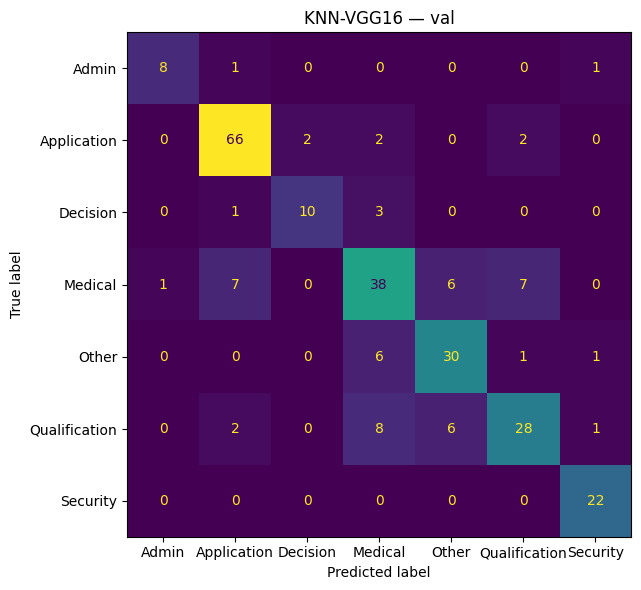


── KNN-VGG16 [test] ──
  Accuracy: 0.7437  |  Macro-F1: 0.7544  |  Weighted-F1: 0.7339
               precision    recall  f1-score   support

        Admin       0.75      0.75      0.75         8
  Application       0.83      0.87      0.85        61
     Decision       1.00      0.62      0.77         8
      Medical       0.63      0.85      0.73        48
        Other       0.75      0.78      0.76        49
Qualification       0.74      0.43      0.55        53
     Security       0.79      1.00      0.88        11

     accuracy                           0.74       238
    macro avg       0.78      0.76      0.75       238
 weighted avg       0.75      0.74      0.73       238



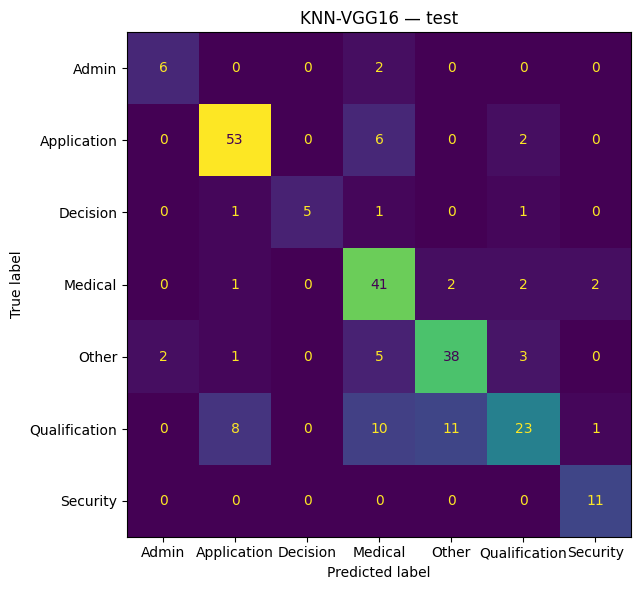

In [49]:
X_vgg_tr_n = normalize(X_vgg_tr)
X_vgg_va_n = normalize(X_vgg_va)
X_vgg_te_n = normalize(X_vgg_te)

knn_vgg = KNeighborsClassifier(n_neighbors=7, metric='cosine', n_jobs=-1)
knn_vgg.fit(X_vgg_tr_n, y_tr)

pred_knn_vgg_va = knn_vgg.predict(X_vgg_va_n)
pred_knn_vgg_te = knn_vgg.predict(X_vgg_te_n)

evaluate('KNN-VGG16', y_va, pred_knn_vgg_va, 'val')
results['KNN-VGG16'] = evaluate('KNN-VGG16', y_te, pred_knn_vgg_te, 'test')
results['KNN-VGG16']['preds_te'] = pred_knn_vgg_te

### 7b. XGBoost-VGG16


── XGBoost-VGG16 [val] ──
  Accuracy: 0.7423  |  Macro-F1: 0.7265  |  Weighted-F1: 0.7450
               precision    recall  f1-score   support

        Admin       0.75      0.60      0.67        10
  Application       0.93      0.90      0.92        72
     Decision       0.80      0.86      0.83        14
      Medical       0.76      0.63      0.69        59
        Other       0.53      0.76      0.62        38
Qualification       0.67      0.67      0.67        45
     Security       0.78      0.64      0.70        22

     accuracy                           0.74       260
    macro avg       0.74      0.72      0.73       260
 weighted avg       0.76      0.74      0.74       260



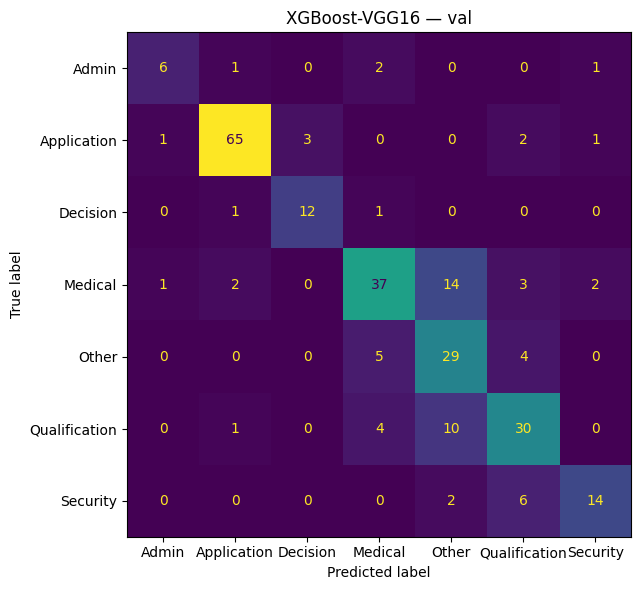


── XGBoost-VGG16 [test] ──
  Accuracy: 0.7395  |  Macro-F1: 0.7861  |  Weighted-F1: 0.7282
               precision    recall  f1-score   support

        Admin       1.00      0.75      0.86         8
  Application       0.86      0.89      0.87        61
     Decision       1.00      0.88      0.93         8
      Medical       0.71      0.75      0.73        48
        Other       0.62      0.88      0.73        49
Qualification       0.65      0.38      0.48        53
     Security       0.91      0.91      0.91        11

     accuracy                           0.74       238
    macro avg       0.82      0.77      0.79       238
 weighted avg       0.74      0.74      0.73       238



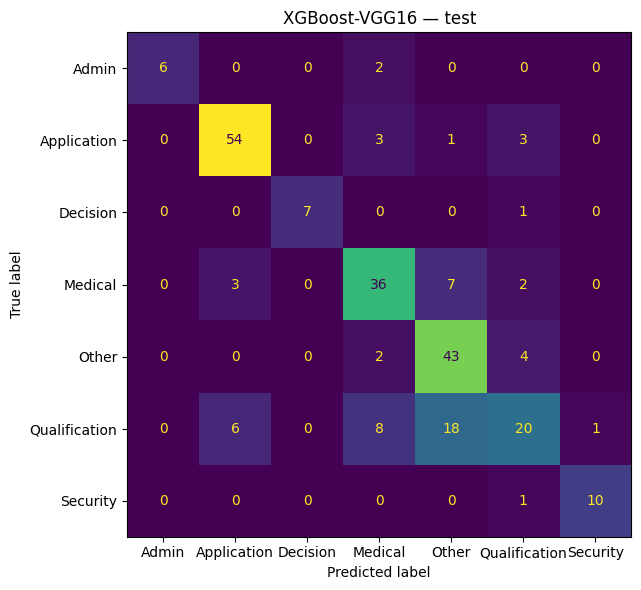

In [50]:
xgb_vgg = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=RANDOM_SEED, n_jobs=-1,
)
xgb_vgg.fit(
    X_vgg_tr, y_tr,
    eval_set=[(X_vgg_va, y_va)],
    verbose=False,
)
pred_xgb_vgg_va = xgb_vgg.predict(X_vgg_va)
pred_xgb_vgg_te = xgb_vgg.predict(X_vgg_te)

evaluate('XGBoost-VGG16', y_va, pred_xgb_vgg_va, 'val')
results['XGBoost-VGG16'] = evaluate('XGBoost-VGG16', y_te, pred_xgb_vgg_te, 'test')
results['XGBoost-VGG16']['preds_te'] = pred_xgb_vgg_te

### 7c. VGG16 Fine-Tuned

VGG16 fine-tune (classifier head only) …
  Epoch  1  val_macro_f1=0.7246
  Epoch  2  val_macro_f1=0.7625
  Epoch  3  val_macro_f1=0.8113
  Epoch  4  val_macro_f1=0.8040
  Epoch  5  val_macro_f1=0.8067
  Epoch  6  val_macro_f1=0.8484
  Epoch  7  val_macro_f1=0.8455
  Epoch  8  val_macro_f1=0.8770
  Epoch  9  val_macro_f1=0.8654
  Epoch 10  val_macro_f1=0.8584
  Epoch 11  val_macro_f1=0.8501
  Epoch 12  val_macro_f1=0.8614
  Epoch 13  val_macro_f1=0.8244
  Epoch 14  val_macro_f1=0.8492
  Epoch 15  val_macro_f1=0.8156

── VGG16 Fine-Tuned [test] ──
  Accuracy: 0.8151  |  Macro-F1: 0.8283  |  Weighted-F1: 0.8136
               precision    recall  f1-score   support

        Admin       1.00      0.62      0.77         8
  Application       0.95      0.89      0.92        61
     Decision       0.78      0.88      0.82         8
      Medical       0.78      0.88      0.82        48
        Other       0.75      0.86      0.80        49
Qualification       0.72      0.62      0.67        5

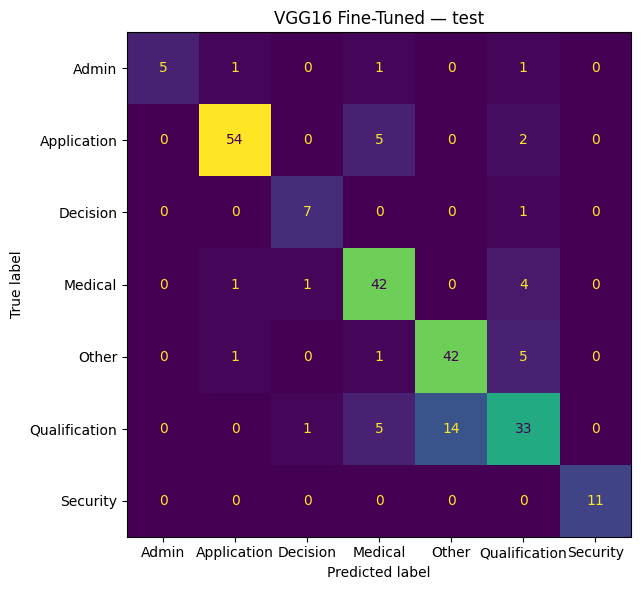

In [53]:
df_tr_sp = start_pages[start_pages['split'] == 'train']
df_va_sp = start_pages[start_pages['split'] == 'val']
df_te_sp = start_pages[start_pages['split'] == 'test']

tr_img_loader, va_img_loader, te_img_loader = make_image_loaders(
    df_tr_sp, df_va_sp, df_te_sp, batch=32)

# build model
vgg_ft = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
vgg_ft.classifier[6] = nn.Linear(4096, NUM_CLASSES)
# freeze features, train classifier only for first 5 epochs (handled inside train_finetune)
for p in vgg_ft.features.parameters():
    p.requires_grad = False
vgg_ft = vgg_ft.to(DEVICE)

print('VGG16 fine-tune (classifier head only) …')
vgg_ft = train_finetune(vgg_ft, tr_img_loader, va_img_loader, n_epochs=15, lr=1e-4)

pred_vgg_ft_te, probs_vgg_ft = predict_image_model(vgg_ft, te_img_loader)
results['VGG16-FT'] = evaluate('VGG16 Fine-Tuned', y_te, pred_vgg_ft_te, 'test')
results['VGG16-FT']['preds_te'] = pred_vgg_ft_te
results['VGG16-FT']['probs_te'] = probs_vgg_ft

### 7d. EfficientNet-B0 Fine-Tuned

EfficientNet-B0 fine-tune …
  Epoch  1  val_macro_f1=0.2060
  Epoch  2  val_macro_f1=0.3373
  Epoch  3  val_macro_f1=0.4551
  Epoch  4  val_macro_f1=0.5489
  Epoch  5  val_macro_f1=0.5766
  Epoch  6  val_macro_f1=0.5966
  Epoch  7  val_macro_f1=0.5968
  Epoch  8  val_macro_f1=0.6443
  Epoch  9  val_macro_f1=0.6410
  Epoch 10  val_macro_f1=0.6212
  Epoch 11  val_macro_f1=0.6164
  Epoch 12  val_macro_f1=0.6592
  Epoch 13  val_macro_f1=0.6454
  Epoch 14  val_macro_f1=0.6437
  Epoch 15  val_macro_f1=0.6291

── EfficientNet-B0 Fine-Tuned [test] ──
  Accuracy: 0.6471  |  Macro-F1: 0.6072  |  Weighted-F1: 0.6586
               precision    recall  f1-score   support

        Admin       0.50      0.88      0.64         8
  Application       0.80      0.77      0.78        61
     Decision       0.35      0.75      0.48         8
      Medical       0.47      0.46      0.46        48
        Other       0.85      0.69      0.76        49
Qualification       0.81      0.57      0.67        53
 

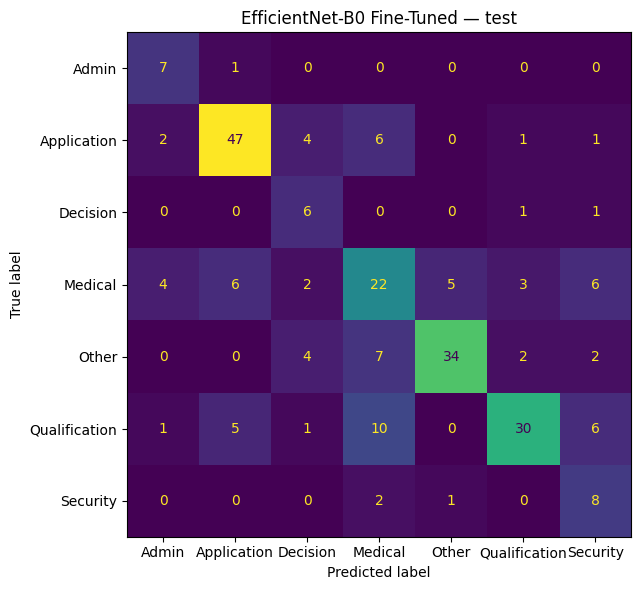

In [54]:
eff_ft = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
in_features = eff_ft.classifier[1].in_features
eff_ft.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, NUM_CLASSES),
)
# freeze backbone
for p in eff_ft.features.parameters():
    p.requires_grad = False
eff_ft = eff_ft.to(DEVICE)

print('EfficientNet-B0 fine-tune …')
eff_ft = train_finetune(eff_ft, tr_img_loader, va_img_loader, n_epochs=15, lr=1e-4)

pred_eff_ft_te, probs_eff_ft = predict_image_model(eff_ft, te_img_loader)
results['EfficientNet-FT'] = evaluate('EfficientNet-B0 Fine-Tuned', y_te, pred_eff_ft_te, 'test')
results['EfficientNet-FT']['preds_te'] = pred_eff_ft_te
results['EfficientNet-FT']['probs_te'] = probs_eff_ft

### 7e. LSTM + VGG-16

Each dossier is treated as an ordered sequence of its **start pages**.
A bidirectional LSTM reads the 4 096-D VGG-16 feature at each step and predicts
the functional category at every start-page position.


In [55]:
class DossierSequenceDataset(Dataset):
    def __init__(self, df: pd.DataFrame, X_feat: np.ndarray):
        self.sequences = []
        for _, grp in df.groupby('dossier'):
            idx   = grp.index.tolist()
            feats = X_feat[idx]
            lbls  = df.loc[idx, 'func_label'].values
            self.sequences.append(
                (torch.tensor(feats, dtype=torch.float32),
                 torch.tensor(lbls,  dtype=torch.long))
            )

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


def pad_collate(batch):
    feats_list, lbls_list = zip(*batch)
    lengths      = torch.tensor([f.size(0) for f in feats_list])
    feats_padded = nn.utils.rnn.pad_sequence(feats_list, batch_first=True)
    lbls_padded  = nn.utils.rnn.pad_sequence(lbls_list,  batch_first=True, padding_value=-1)
    return feats_padded, lbls_padded, lengths


# df_tr_sp / df_va_sp / df_te_sp already defined in cell 7c (VGG16 fine-tune)
lstm_tr_ds = DossierSequenceDataset(df_tr_sp, X_vgg)
lstm_va_ds = DossierSequenceDataset(df_va_sp, X_vgg)
lstm_te_ds = DossierSequenceDataset(df_te_sp, X_vgg)

lstm_tr_loader = DataLoader(lstm_tr_ds, batch_size=4, shuffle=True,  collate_fn=pad_collate)
lstm_va_loader = DataLoader(lstm_va_ds, batch_size=4, shuffle=False, collate_fn=pad_collate)
lstm_te_loader = DataLoader(lstm_te_ds, batch_size=4, shuffle=False, collate_fn=pad_collate)
print(f'Train dossiers: {len(lstm_tr_ds)},  Val: {len(lstm_va_ds)},  Test: {len(lstm_te_ds)}')


Train dossiers: 45,  Val: 10,  Test: 10


In [56]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim=4096, hidden_dim=256, num_layers=2,
                 dropout=0.3, n_classes=NUM_CLASSES):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True,
        )
        self.head = nn.Linear(hidden_dim * 2, n_classes)

    def forward(self, x, lengths=None):
        x = self.proj(x)
        if lengths is not None:
            x = nn.utils.rnn.pack_padded_sequence(
                x, lengths.cpu(), batch_first=True, enforce_sorted=False
            )
        out, _ = self.lstm(x)
        if lengths is not None:
            out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        return self.head(out)   # (B, T, n_classes)


def train_lstm(model, tr_loader, va_loader, n_epochs=20, lr=1e-3):
    criterion = nn.CrossEntropyLoss(
        weight=class_weights_tensor(y_tr, NUM_CLASSES, DEVICE),
        ignore_index=-1,
    )
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

    best_val_f1, best_state = -1, None

    for epoch in range(1, n_epochs + 1):
        model.train()
        total_loss, n = 0, 0
        for feats, lbls, lengths in tr_loader:
            feats, lbls = feats.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            logits = model(feats, lengths)     # (B, T, C)
            B, T, C = logits.shape
            loss = criterion(logits.view(B * T, C), lbls.view(B * T))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            mask = lbls.view(B * T) != -1
            total_loss += loss.item() * mask.sum().item()
            n          += mask.sum().item()
        scheduler.step()

        model.eval()
        all_p, all_t = [], []
        with torch.no_grad():
            for feats, lbls, lengths in va_loader:
                feats  = feats.to(DEVICE)
                logits = model(feats, lengths)
                B, T, C = logits.shape
                preds = logits.argmax(-1).cpu().numpy().ravel()
                truth = lbls.numpy().ravel()
                mask  = truth != -1
                all_p.extend(preds[mask])
                all_t.extend(truth[mask])
        val_f1 = f1_score(all_t, all_p, average='macro', zero_division=0)
        print(f'Epoch {epoch:2d}  loss={total_loss / max(n, 1):.4f}  val_macro_f1={val_f1:.4f}')
        if val_f1 >= best_val_f1:
            best_val_f1 = val_f1
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model


lstm_model = LSTMClassifier(
    input_dim=4096, hidden_dim=256, num_layers=2,
    dropout=0.3, n_classes=NUM_CLASSES,
).to(DEVICE)
print(f'LSTM params: {sum(p.numel() for p in lstm_model.parameters()):,}')
lstm_model = train_lstm(lstm_model, lstm_tr_loader, lstm_va_loader, n_epochs=20, lr=1e-3)


LSTM params: 5,255,175
Epoch  1  loss=1.8515  val_macro_f1=0.3548
Epoch  2  loss=1.4128  val_macro_f1=0.4528
Epoch  3  loss=0.9428  val_macro_f1=0.6432
Epoch  4  loss=0.7343  val_macro_f1=0.7234
Epoch  5  loss=0.6138  val_macro_f1=0.7750
Epoch  6  loss=0.4835  val_macro_f1=0.7662
Epoch  7  loss=0.4270  val_macro_f1=0.8277
Epoch  8  loss=0.3355  val_macro_f1=0.7732
Epoch  9  loss=0.2837  val_macro_f1=0.7849
Epoch 10  loss=0.2722  val_macro_f1=0.7743
Epoch 11  loss=0.2369  val_macro_f1=0.8204
Epoch 12  loss=0.1943  val_macro_f1=0.8286
Epoch 13  loss=0.1844  val_macro_f1=0.8029
Epoch 14  loss=0.1431  val_macro_f1=0.8405
Epoch 15  loss=0.1231  val_macro_f1=0.8336
Epoch 16  loss=0.1094  val_macro_f1=0.8419
Epoch 17  loss=0.1129  val_macro_f1=0.8080
Epoch 18  loss=0.1020  val_macro_f1=0.8444
Epoch 19  loss=0.0897  val_macro_f1=0.8272
Epoch 20  loss=0.0869  val_macro_f1=0.8342



── LSTM + VGG-16 [test] ──
  Accuracy: 0.7857  |  Macro-F1: 0.8258  |  Weighted-F1: 0.7772
               precision    recall  f1-score   support

        Admin       0.88      0.88      0.88         8
  Application       0.90      0.87      0.88        61
     Decision       1.00      0.88      0.93         8
      Medical       0.62      0.81      0.70        48
        Other       0.77      0.94      0.84        49
Qualification       0.83      0.45      0.59        53
     Security       0.92      1.00      0.96        11

     accuracy                           0.79       238
    macro avg       0.84      0.83      0.83       238
 weighted avg       0.80      0.79      0.78       238



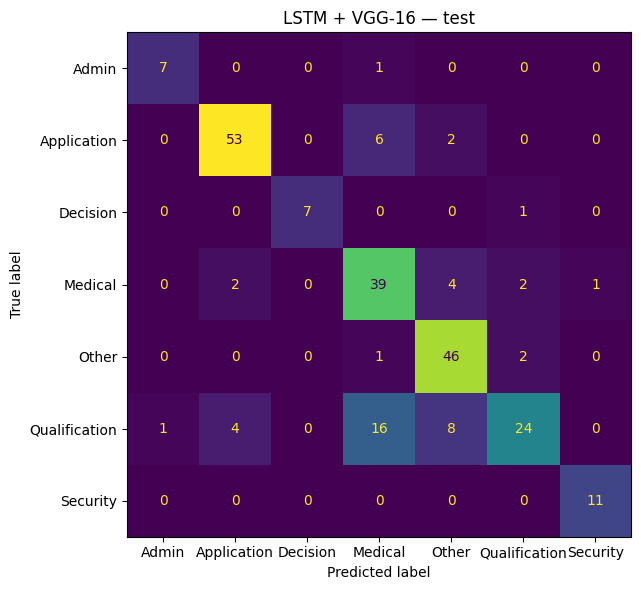

In [57]:
lstm_model.eval()
all_true_lstm, all_pred_lstm = [], []
with torch.no_grad():
    for feats, lbls, lengths in lstm_te_loader:
        feats  = feats.to(DEVICE)
        logits = lstm_model(feats, lengths)
        preds  = logits.argmax(-1).cpu().numpy()
        truth  = lbls.numpy()
        mask   = truth != -1
        all_true_lstm.extend(truth[mask].tolist())
        all_pred_lstm.extend(preds[mask].tolist())

pred_lstm_te = np.array(all_pred_lstm)
true_lstm_te = np.array(all_true_lstm)
results['LSTM-VGG16'] = evaluate('LSTM + VGG-16', true_lstm_te, pred_lstm_te, 'test')
results['LSTM-VGG16']['preds_te'] = pred_lstm_te


---
## 8. Text-Only Models

### 8a. KNN-BERT


── KNN-BERT [val] ──
  Accuracy: 0.8462  |  Macro-F1: 0.8306  |  Weighted-F1: 0.8467
               precision    recall  f1-score   support

        Admin       0.58      0.70      0.64        10
  Application       0.93      0.90      0.92        72
     Decision       0.93      0.93      0.93        14
      Medical       0.77      0.83      0.80        59
        Other       0.85      0.76      0.81        38
Qualification       0.90      0.78      0.83        45
     Security       0.81      1.00      0.90        22

     accuracy                           0.85       260
    macro avg       0.82      0.84      0.83       260
 weighted avg       0.85      0.85      0.85       260



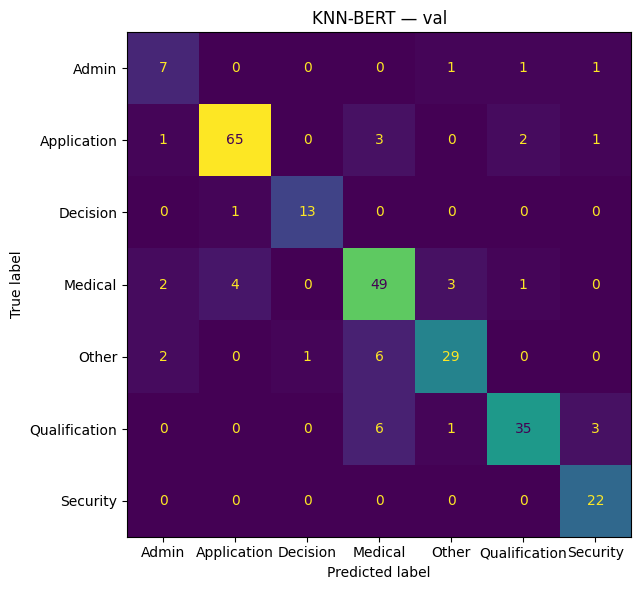


── KNN-BERT [test] ──
  Accuracy: 0.8445  |  Macro-F1: 0.8179  |  Weighted-F1: 0.8470
               precision    recall  f1-score   support

        Admin       0.46      0.75      0.57         8
  Application       0.89      0.89      0.89        61
     Decision       1.00      0.75      0.86         8
      Medical       0.77      0.92      0.84        48
        Other       0.91      0.84      0.87        49
Qualification       0.93      0.74      0.82        53
     Security       0.79      1.00      0.88        11

     accuracy                           0.84       238
    macro avg       0.82      0.84      0.82       238
 weighted avg       0.86      0.84      0.85       238



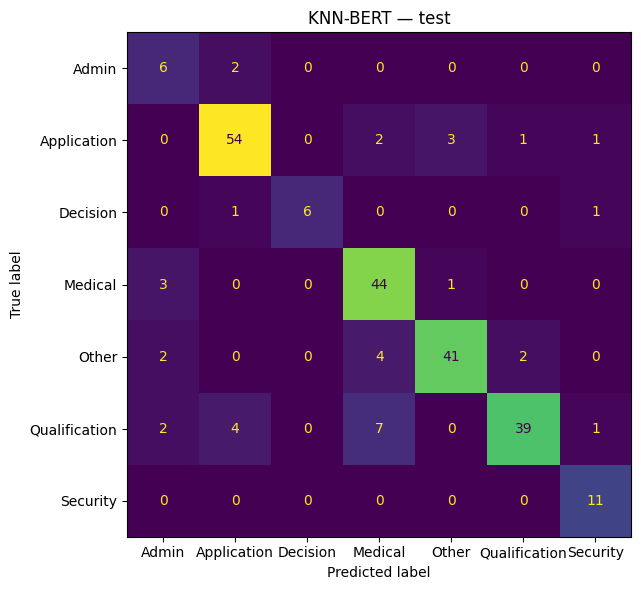

In [58]:
X_bert_tr_n = normalize(X_bert_tr)
X_bert_va_n = normalize(X_bert_va)
X_bert_te_n = normalize(X_bert_te)

knn_bert = KNeighborsClassifier(n_neighbors=7, metric='cosine', n_jobs=-1)
knn_bert.fit(X_bert_tr_n, y_tr)

pred_knn_bert_va = knn_bert.predict(X_bert_va_n)
pred_knn_bert_te = knn_bert.predict(X_bert_te_n)

evaluate('KNN-BERT', y_va, pred_knn_bert_va, 'val')
results['KNN-BERT'] = evaluate('KNN-BERT', y_te, pred_knn_bert_te, 'test')
results['KNN-BERT']['preds_te'] = pred_knn_bert_te

### 8b. XGBoost-BERT


── XGBoost-BERT [val] ──
  Accuracy: 0.9038  |  Macro-F1: 0.8886  |  Weighted-F1: 0.9035
               precision    recall  f1-score   support

        Admin       1.00      0.60      0.75        10
  Application       0.95      0.97      0.96        72
     Decision       1.00      0.86      0.92        14
      Medical       0.84      0.86      0.85        59
        Other       0.80      0.92      0.85        38
Qualification       0.98      0.89      0.93        45
     Security       0.95      0.95      0.95        22

     accuracy                           0.90       260
    macro avg       0.93      0.87      0.89       260
 weighted avg       0.91      0.90      0.90       260



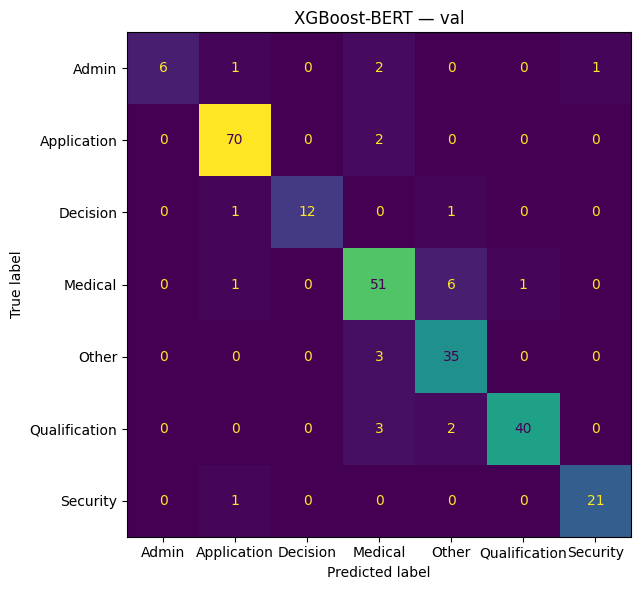


── XGBoost-BERT [test] ──
  Accuracy: 0.8782  |  Macro-F1: 0.8622  |  Weighted-F1: 0.8769
               precision    recall  f1-score   support

        Admin       0.75      0.75      0.75         8
  Application       0.86      0.92      0.89        61
     Decision       1.00      0.62      0.77         8
      Medical       0.84      0.88      0.86        48
        Other       0.85      0.96      0.90        49
Qualification       0.95      0.79      0.87        53
     Security       1.00      1.00      1.00        11

     accuracy                           0.88       238
    macro avg       0.89      0.85      0.86       238
 weighted avg       0.88      0.88      0.88       238



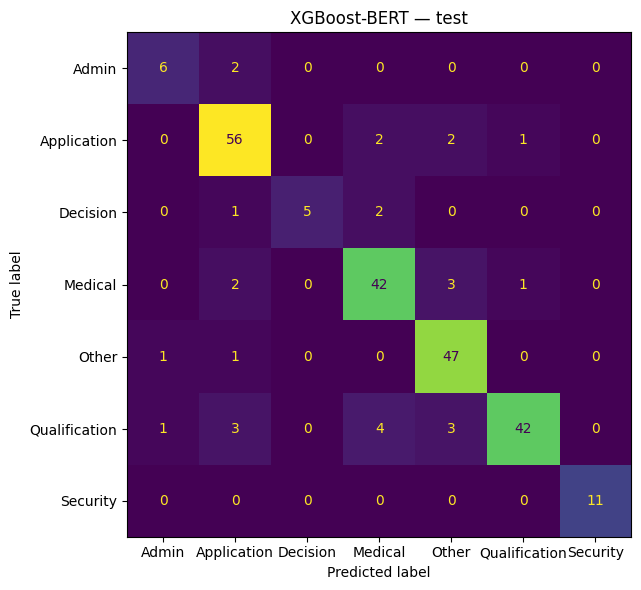

In [59]:
xgb_bert = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=RANDOM_SEED, n_jobs=-1,
)
xgb_bert.fit(
    X_bert_tr, y_tr,
    eval_set=[(X_bert_va, y_va)],
    verbose=False,
)
pred_xgb_bert_va = xgb_bert.predict(X_bert_va)
pred_xgb_bert_te = xgb_bert.predict(X_bert_te)

evaluate('XGBoost-BERT', y_va, pred_xgb_bert_va, 'val')
results['XGBoost-BERT'] = evaluate('XGBoost-BERT', y_te, pred_xgb_bert_te, 'test')
results['XGBoost-BERT']['preds_te'] = pred_xgb_bert_te

### 8c. TEXT-CNN

1D convolutional network over BERT token embeddings (frozen BERT backbone),
with filter sizes 2 / 3 / 4 and max-over-time pooling.

In [60]:
class TextDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int = 256):
        self.texts     = [safe_read_text(p) for p in df['text_path'].tolist()]
        self.labels    = df['func_label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self): return len(self.texts)

    def __getitem__(self, i):
        enc = self.tokenizer(
            self.texts[i], padding='max_length', truncation=True,
            max_length=self.max_len, return_tensors='pt',
        )
        return (
            enc['input_ids'].squeeze(0),
            enc['attention_mask'].squeeze(0),
            torch.tensor(self.labels[i], dtype=torch.long),
        )


class TextCNN(nn.Module):
    """
    Frozen BERT embeddings → multi-scale 1D-CNN → max-over-time pool
    → concat → dropout → linear.
    """
    def __init__(
        self, bert_model,
        embed_dim: int = 768,
        num_filters: int = 128,
        filter_sizes: tuple = (2, 3, 4),
        num_classes: int = NUM_CLASSES,
        dropout: float = 0.4,
    ):
        super().__init__()
        self.bert = bert_model  # frozen
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            out  = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            emb  = out.last_hidden_state  # (B, T, E)
        x = emb.transpose(1, 2)           # (B, E, T)
        pooled = [F.max_pool1d(F.relu(conv(x)), x.size(2) - conv.kernel_size[0] + 1).squeeze(2)
                  for conv in self.convs]
        cat = self.dropout(torch.cat(pooled, dim=1))
        return self.fc(cat)


tcnn_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL, use_fast=True)
tcnn_bert_base = AutoModel.from_pretrained(BERT_MODEL).to(DEVICE)
for p in tcnn_bert_base.parameters():
    p.requires_grad = False

tcnn_tr_ds = TextDataset(df_tr_sp, tcnn_tokenizer)
tcnn_va_ds = TextDataset(df_va_sp, tcnn_tokenizer)
tcnn_te_ds = TextDataset(df_te_sp, tcnn_tokenizer)

tcnn_tr_loader = DataLoader(tcnn_tr_ds, batch_size=16, shuffle=True,  num_workers=0)
tcnn_va_loader = DataLoader(tcnn_va_ds, batch_size=16, shuffle=False, num_workers=0)
tcnn_te_loader = DataLoader(tcnn_te_ds, batch_size=16, shuffle=False, num_workers=0)

tcnn_model = TextCNN(tcnn_bert_base).to(DEVICE)
trainable  = sum(p.numel() for p in tcnn_model.parameters() if p.requires_grad)
print(f'TEXT-CNN trainable params: {trainable:,}')

TEXT-CNN trainable params: 887,815


Training TEXT-CNN …
  Epoch  1  val_macro_f1=0.8668
  Epoch  2  val_macro_f1=0.8841
  Epoch  3  val_macro_f1=0.9018
  Epoch  4  val_macro_f1=0.8957
  Epoch  5  val_macro_f1=0.8962
  Epoch  6  val_macro_f1=0.9062
  Epoch  7  val_macro_f1=0.9261
  Epoch  8  val_macro_f1=0.9143
  Epoch  9  val_macro_f1=0.8934
  Epoch 10  val_macro_f1=0.8998
  Epoch 11  val_macro_f1=0.9118
  Epoch 12  val_macro_f1=0.9171
  Epoch 13  val_macro_f1=0.9116
  Epoch 14  val_macro_f1=0.9257
  Epoch 15  val_macro_f1=0.9116

── TEXT-CNN [test] ──
  Accuracy: 0.8824  |  Macro-F1: 0.8709  |  Weighted-F1: 0.8859
               precision    recall  f1-score   support

        Admin       0.43      0.75      0.55         8
  Application       0.95      0.89      0.92        61
     Decision       1.00      1.00      1.00         8
      Medical       0.83      0.94      0.88        48
        Other       0.87      0.94      0.90        49
Qualification       0.98      0.75      0.85        53
     Security       1.00   

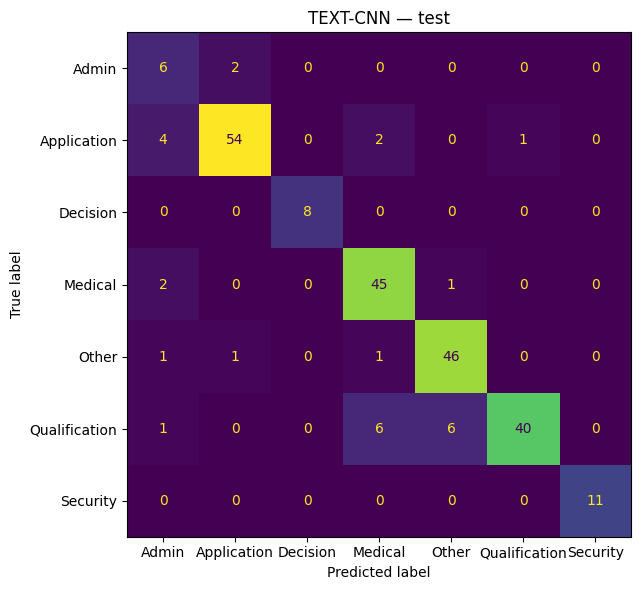

In [61]:
def train_text_model(model, tr_loader, va_loader, n_epochs=15, lr=1e-3):
    cw   = class_weights_tensor(y_tr, NUM_CLASSES, DEVICE)
    crit = nn.CrossEntropyLoss(weight=cw)
    # only train non-BERT parameters
    opt  = optim.Adam([p for p in model.parameters() if p.requires_grad],
                      lr=lr, weight_decay=1e-5)
    sch  = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)

    best_f1, best_state = -1, None
    for epoch in range(1, n_epochs + 1):
        model.train()
        for ids, mask, yb in tr_loader:
            ids, mask, yb = ids.to(DEVICE), mask.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(ids, mask), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sch.step()

        model.eval()
        preds = []
        with torch.no_grad():
            for ids, mask, _ in va_loader:
                preds.extend(model(ids.to(DEVICE), mask.to(DEVICE)).argmax(1).cpu().tolist())
        f1 = f1_score(y_va, preds, average='macro', zero_division=0)
        print(f'  Epoch {epoch:2d}  val_macro_f1={f1:.4f}')
        if f1 > best_f1:
            best_f1   = f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model


def predict_text_model(model, loader):
    model.eval()
    preds, probs_list = [], []
    with torch.no_grad():
        for ids, mask, _ in loader:
            logits = model(ids.to(DEVICE), mask.to(DEVICE))
            probs_list.append(F.softmax(logits, dim=1).cpu().numpy())
            preds.extend(logits.argmax(1).cpu().tolist())
    return np.array(preds), np.vstack(probs_list)


print('Training TEXT-CNN …')
tcnn_model = train_text_model(tcnn_model, tcnn_tr_loader, tcnn_va_loader, n_epochs=15, lr=1e-3)
pred_tcnn_te, probs_tcnn = predict_text_model(tcnn_model, tcnn_te_loader)
results['TEXT-CNN'] = evaluate('TEXT-CNN', y_te, pred_tcnn_te, 'test')
results['TEXT-CNN']['preds_te'] = pred_tcnn_te
results['TEXT-CNN']['probs_te'] = probs_tcnn

### 8d. BERT Fine-Tuned

BERT fine-tune total params: 109,487,623
Training BERT fine-tuned …
  Epoch  1  val_macro_f1=0.9070
  Epoch  2  val_macro_f1=0.9150
  Epoch  3  val_macro_f1=0.9279
  Epoch  4  val_macro_f1=0.9057
  Epoch  5  val_macro_f1=0.9100
  Epoch  6  val_macro_f1=0.9143
  Epoch  7  val_macro_f1=0.9228
  Epoch  8  val_macro_f1=0.9172
  Epoch  9  val_macro_f1=0.9148
  Epoch 10  val_macro_f1=0.9143

── BERT Fine-Tuned [test] ──
  Accuracy: 0.8613  |  Macro-F1: 0.8743  |  Weighted-F1: 0.8613
               precision    recall  f1-score   support

        Admin       1.00      0.75      0.86         8
  Application       0.93      0.89      0.91        61
     Decision       1.00      0.88      0.93         8
      Medical       0.74      0.94      0.83        48
        Other       0.83      0.90      0.86        49
Qualification       0.95      0.72      0.82        53
     Security       0.85      1.00      0.92        11

     accuracy                           0.86       238
    macro avg       0

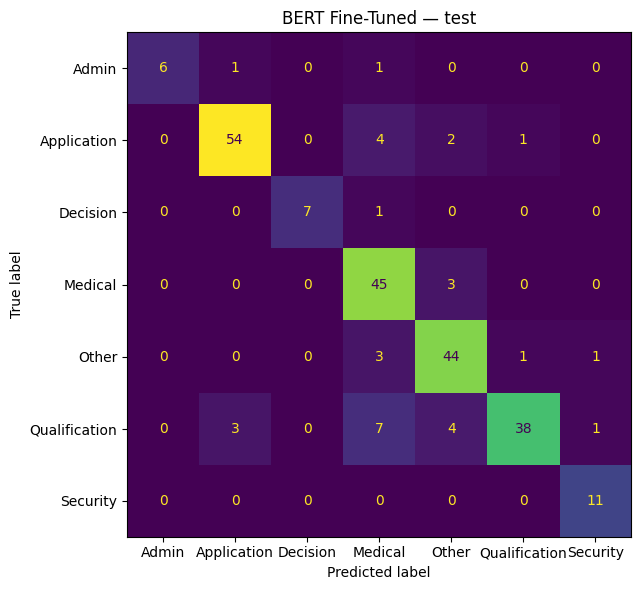

In [62]:
class BERTClassifier(nn.Module):
    def __init__(self, model_name: str = BERT_MODEL,
                 num_classes: int = NUM_CLASSES, dropout: float = 0.1):
        super().__init__()
        self.bert       = AutoModel.from_pretrained(model_name)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.bert.config.hidden_size, num_classes),
        )

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(out.last_hidden_state[:, 0, :])


bert_ft_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL, use_fast=True)
bert_ft_tr_ds = TextDataset(df_tr_sp, bert_ft_tokenizer)
bert_ft_va_ds = TextDataset(df_va_sp, bert_ft_tokenizer)
bert_ft_te_ds = TextDataset(df_te_sp, bert_ft_tokenizer)
bert_ft_tr_loader = DataLoader(bert_ft_tr_ds, batch_size=8,  shuffle=True,  num_workers=0)
bert_ft_va_loader = DataLoader(bert_ft_va_ds, batch_size=16, shuffle=False, num_workers=0)
bert_ft_te_loader = DataLoader(bert_ft_te_ds, batch_size=16, shuffle=False, num_workers=0)

bert_clf = BERTClassifier().to(DEVICE)
print(f'BERT fine-tune total params: {sum(p.numel() for p in bert_clf.parameters()):,}')

print('Training BERT fine-tuned …')
bert_clf = train_text_model(bert_clf, bert_ft_tr_loader, bert_ft_va_loader,
                             n_epochs=10, lr=2e-5)

pred_bert_ft_te, probs_bert_ft = predict_text_model(bert_clf, bert_ft_te_loader)
results['BERT-FT'] = evaluate('BERT Fine-Tuned', y_te, pred_bert_ft_te, 'test')
results['BERT-FT']['preds_te'] = pred_bert_ft_te
results['BERT-FT']['probs_te'] = probs_bert_ft

---
## 9. Multimodal / Ensemble Models

### 9a. KNN-Ensemble (VGG16 + BERT concatenated features)


── KNN-Ensemble [val] ──
  Accuracy: 0.8269  |  Macro-F1: 0.8387  |  Weighted-F1: 0.8265
               precision    recall  f1-score   support

        Admin       0.89      0.80      0.84        10
  Application       0.87      0.90      0.88        72
     Decision       0.92      0.79      0.85        14
      Medical       0.72      0.75      0.73        59
        Other       0.88      0.76      0.82        38
Qualification       0.78      0.80      0.79        45
     Security       0.92      1.00      0.96        22

     accuracy                           0.83       260
    macro avg       0.85      0.83      0.84       260
 weighted avg       0.83      0.83      0.83       260



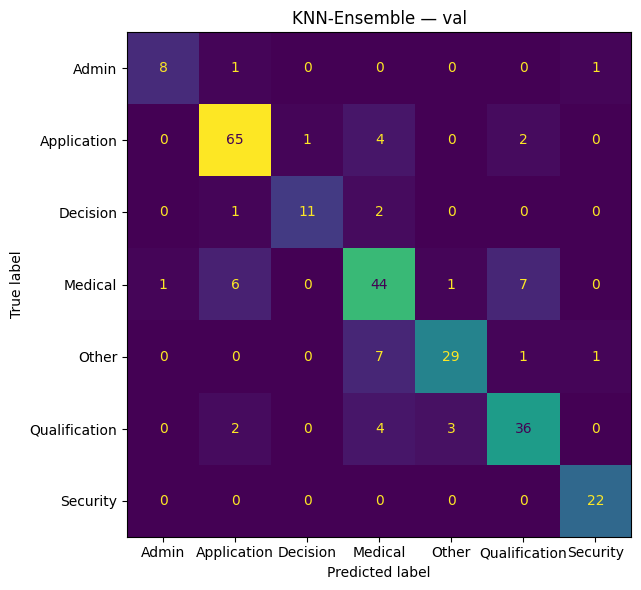


── KNN-Ensemble [test] ──
  Accuracy: 0.8235  |  Macro-F1: 0.8361  |  Weighted-F1: 0.8191
               precision    recall  f1-score   support

        Admin       0.88      0.88      0.88         8
  Application       0.90      0.89      0.89        61
     Decision       1.00      0.75      0.86         8
      Medical       0.69      0.96      0.80        48
        Other       0.88      0.86      0.87        49
Qualification       0.86      0.57      0.68        53
     Security       0.79      1.00      0.88        11

     accuracy                           0.82       238
    macro avg       0.85      0.84      0.84       238
 weighted avg       0.84      0.82      0.82       238



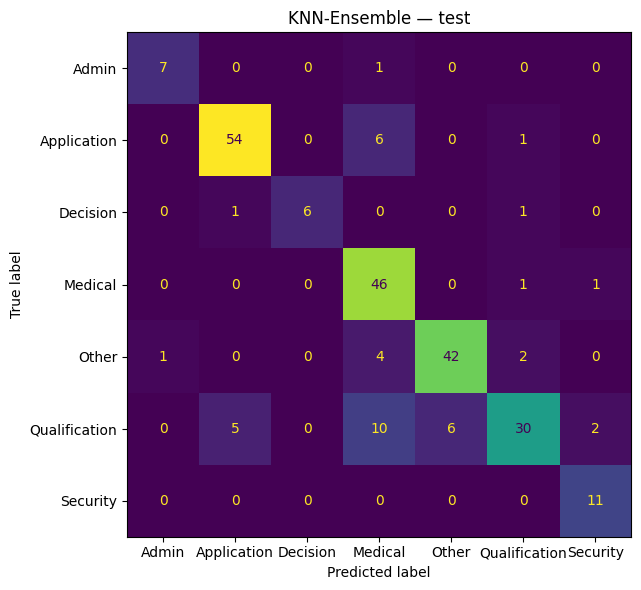

In [63]:
# Concatenate L2-normalised VGG16 and BERT features
X_ens_tr = np.hstack([normalize(X_vgg_tr), normalize(X_bert_tr)])
X_ens_va = np.hstack([normalize(X_vgg_va), normalize(X_bert_va)])
X_ens_te = np.hstack([normalize(X_vgg_te), normalize(X_bert_te)])

knn_ens = KNeighborsClassifier(n_neighbors=7, metric='cosine', n_jobs=-1)
knn_ens.fit(X_ens_tr, y_tr)

pred_knn_ens_va = knn_ens.predict(X_ens_va)
pred_knn_ens_te = knn_ens.predict(X_ens_te)

evaluate('KNN-Ensemble', y_va, pred_knn_ens_va, 'val')
results['KNN-Ensemble'] = evaluate('KNN-Ensemble', y_te, pred_knn_ens_te, 'test')
results['KNN-Ensemble']['preds_te'] = pred_knn_ens_te

### 9b. XGBoost-Ensemble (VGG16 + BERT concatenated features)


── XGBoost-Ensemble [val] ──
  Accuracy: 0.9115  |  Macro-F1: 0.8958  |  Weighted-F1: 0.9105
               precision    recall  f1-score   support

        Admin       0.86      0.60      0.71        10
  Application       0.96      0.96      0.96        72
     Decision       1.00      0.93      0.96        14
      Medical       0.85      0.86      0.86        59
        Other       0.88      0.92      0.90        38
Qualification       0.91      0.91      0.91        45
     Security       0.96      1.00      0.98        22

     accuracy                           0.91       260
    macro avg       0.92      0.88      0.90       260
 weighted avg       0.91      0.91      0.91       260



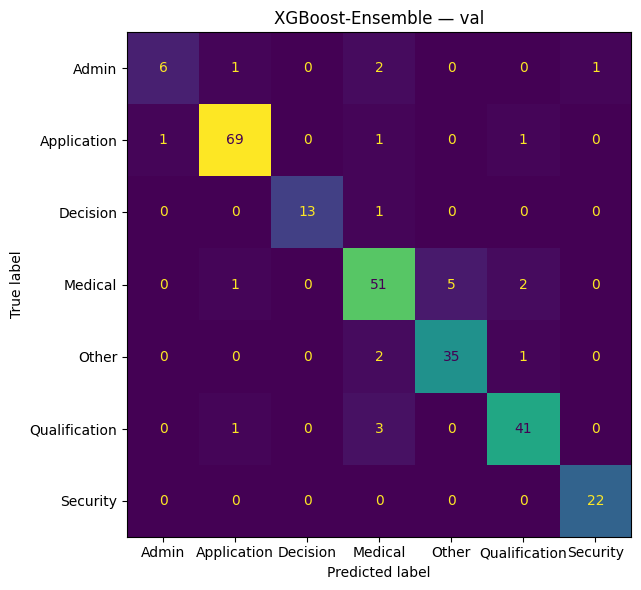


── XGBoost-Ensemble [test] ──
  Accuracy: 0.8739  |  Macro-F1: 0.8927  |  Weighted-F1: 0.8741
               precision    recall  f1-score   support

        Admin       1.00      0.75      0.86         8
  Application       0.92      0.89      0.90        61
     Decision       1.00      0.88      0.93         8
      Medical       0.73      0.98      0.84        48
        Other       0.90      0.90      0.90        49
Qualification       0.93      0.74      0.82        53
     Security       1.00      1.00      1.00        11

     accuracy                           0.87       238
    macro avg       0.93      0.87      0.89       238
 weighted avg       0.89      0.87      0.87       238



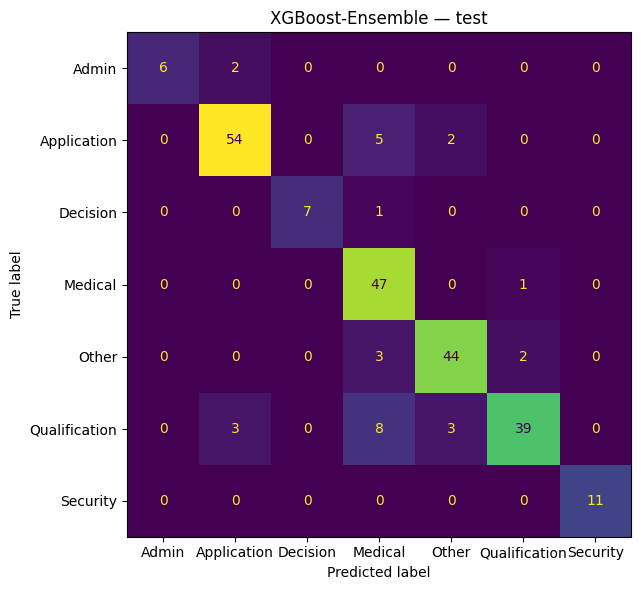

In [64]:
xgb_ens = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.5,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=RANDOM_SEED, n_jobs=-1,
)
xgb_ens.fit(
    X_ens_tr, y_tr,
    eval_set=[(X_ens_va, y_va)],
    verbose=False,
)
pred_xgb_ens_va = xgb_ens.predict(X_ens_va)
pred_xgb_ens_te = xgb_ens.predict(X_ens_te)

evaluate('XGBoost-Ensemble', y_va, pred_xgb_ens_va, 'val')
results['XGBoost-Ensemble'] = evaluate('XGBoost-Ensemble', y_te, pred_xgb_ens_te, 'test')
results['XGBoost-Ensemble']['preds_te'] = pred_xgb_ens_te

### 9c. Early Fusion — BERT + EfficientNet

Frozen EfficientNet-B0 (1280-D) features concatenated with frozen BERT [CLS] (768-D)
features → shared MLP head trained from scratch.

  Epoch  1  val_macro_f1=0.7389
  Epoch  2  val_macro_f1=0.8812
  Epoch  3  val_macro_f1=0.9021
  Epoch  4  val_macro_f1=0.9090
  Epoch  5  val_macro_f1=0.8800
  Epoch  6  val_macro_f1=0.9288
  Epoch  7  val_macro_f1=0.9481
  Epoch  8  val_macro_f1=0.9285
  Epoch  9  val_macro_f1=0.9423
  Epoch 10  val_macro_f1=0.9220
  Epoch 11  val_macro_f1=0.9387
  Epoch 12  val_macro_f1=0.9286
  Epoch 13  val_macro_f1=0.9386
  Epoch 14  val_macro_f1=0.9298
  Epoch 15  val_macro_f1=0.9253
  Epoch 16  val_macro_f1=0.9321
  Epoch 17  val_macro_f1=0.9225
  Epoch 18  val_macro_f1=0.9218
  Epoch 19  val_macro_f1=0.9394
  Epoch 20  val_macro_f1=0.9313

── Early Fusion BERT+EfficientNet [test] ──
  Accuracy: 0.8908  |  Macro-F1: 0.8981  |  Weighted-F1: 0.8890
               precision    recall  f1-score   support

        Admin       1.00      0.75      0.86         8
  Application       0.93      0.89      0.91        61
     Decision       1.00      0.88      0.93         8
      Medical       0.84      

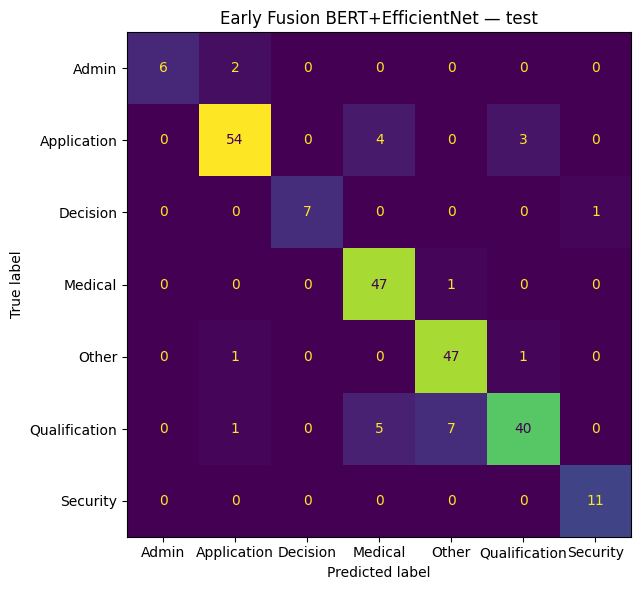

In [65]:
class EarlyFusionDataset(Dataset):
    def __init__(self, img_feats: np.ndarray, text_feats: np.ndarray, labels: np.ndarray):
        self.img   = torch.tensor(img_feats,  dtype=torch.float32)
        self.text  = torch.tensor(text_feats, dtype=torch.float32)
        self.labels = torch.tensor(labels,    dtype=torch.long)

    def __len__(self): return len(self.labels)
    def __getitem__(self, i): return self.img[i], self.text[i], self.labels[i]


class EarlyFusionClassifier(nn.Module):
    def __init__(self, img_dim=1280, text_dim=768,
                 hidden=512, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.img_proj  = nn.Linear(img_dim,  hidden)
        self.text_proj = nn.Linear(text_dim, hidden)
        self.head = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, img_feat, text_feat):
        return self.head(torch.cat([
            self.img_proj(img_feat),
            self.text_proj(text_feat),
        ], dim=1))


ef_tr_loader = DataLoader(
    EarlyFusionDataset(X_eff_tr, X_bert_tr, y_tr), batch_size=32, shuffle=True)
ef_va_loader = DataLoader(
    EarlyFusionDataset(X_eff_va, X_bert_va, y_va), batch_size=32, shuffle=False)
ef_te_loader = DataLoader(
    EarlyFusionDataset(X_eff_te, X_bert_te, y_te), batch_size=32, shuffle=False)

ef_model = EarlyFusionClassifier().to(DEVICE)
cw   = class_weights_tensor(y_tr, NUM_CLASSES, DEVICE)
crit = nn.CrossEntropyLoss(weight=cw)
opt  = optim.Adam(ef_model.parameters(), lr=1e-3, weight_decay=1e-5)
sch  = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)

best_f1, best_state = -1, None
for epoch in range(1, 21):
    ef_model.train()
    for img_f, txt_f, yb in ef_tr_loader:
        img_f, txt_f, yb = img_f.to(DEVICE), txt_f.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        crit(ef_model(img_f, txt_f), yb).backward()
        opt.step()
    sch.step()

    ef_model.eval()
    preds = []
    with torch.no_grad():
        for img_f, txt_f, _ in ef_va_loader:
            preds.extend(ef_model(img_f.to(DEVICE), txt_f.to(DEVICE)).argmax(1).cpu().tolist())
    f1 = f1_score(y_va, preds, average='macro', zero_division=0)
    print(f'  Epoch {epoch:2d}  val_macro_f1={f1:.4f}')
    if f1 > best_f1:
        best_f1, best_state = f1, {k: v.clone() for k, v in ef_model.state_dict().items()}

ef_model.load_state_dict(best_state)
ef_model.eval()
pred_ef_te, probs_ef = [], []
with torch.no_grad():
    for img_f, txt_f, _ in ef_te_loader:
        logits = ef_model(img_f.to(DEVICE), txt_f.to(DEVICE))
        probs_ef.append(F.softmax(logits, dim=1).cpu().numpy())
        pred_ef_te.extend(logits.argmax(1).cpu().tolist())
pred_ef_te = np.array(pred_ef_te)
probs_ef   = np.vstack(probs_ef)

results['EarlyFusion'] = evaluate('Early Fusion BERT+EfficientNet', y_te, pred_ef_te, 'test')
results['EarlyFusion']['preds_te'] = pred_ef_te
results['EarlyFusion']['probs_te'] = probs_ef

### 9d. Late Fusion — BERT + EfficientNet (average softmax)

Average the softmax probabilities from the individually trained
`BERT Fine-Tuned` and `EfficientNet Fine-Tuned` models.


── Late Fusion BERT+EfficientNet [test] ──
  Accuracy: 0.8571  |  Macro-F1: 0.8607  |  Weighted-F1: 0.8564
               precision    recall  f1-score   support

        Admin       1.00      0.62      0.77         8
  Application       0.92      0.89      0.90        61
     Decision       1.00      0.88      0.93         8
      Medical       0.74      0.94      0.83        48
        Other       0.83      0.90      0.86        49
Qualification       0.95      0.72      0.82        53
     Security       0.85      1.00      0.92        11

     accuracy                           0.86       238
    macro avg       0.90      0.85      0.86       238
 weighted avg       0.87      0.86      0.86       238



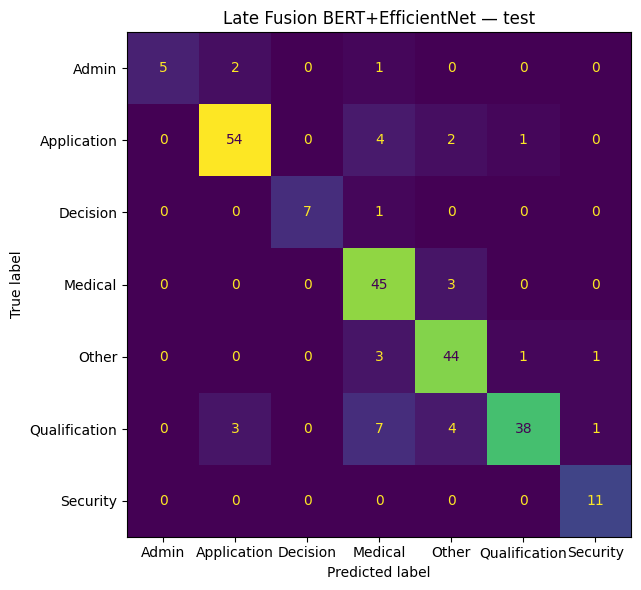

In [66]:
probs_bert_arr = results['BERT-FT']['probs_te']   # (N_te, 7)
probs_eff_arr  = results['EfficientNet-FT']['probs_te']  # (N_te, 7)

probs_late = (probs_bert_arr + probs_eff_arr) / 2.0
pred_late  = probs_late.argmax(axis=1)

results['LateFusion'] = evaluate('Late Fusion BERT+EfficientNet', y_te, pred_late, 'test')
results['LateFusion']['preds_te'] = pred_late
results['LateFusion']['probs_te'] = probs_late

## 10. Summary

In [67]:
metric_keys = ['accuracy', 'macro_f1', 'weighted_f1'] + [f'f1_{n}' for n in SHORT_NAMES]

summary_rows = {}
for name, d in results.items():
    row = {k: d.get(k, float('nan')) for k in metric_keys}
    # Fall back: compute missing metrics from stored preds_te
    if np.isnan(row.get('weighted_f1', float('nan'))) and 'preds_te' in d:
        rep = classification_report(
            y_te, d['preds_te'],
            target_names=SHORT_NAMES,
            output_dict=True,
            zero_division=0,
        )
        row['weighted_f1'] = rep['weighted avg']['f1-score']
        for n in SHORT_NAMES:
            row[f'f1_{n}'] = rep[n]['f1-score']
    summary_rows[name] = row

summary_df = pd.DataFrame(summary_rows).T.round(4)
summary_df.index.name = 'Model'
print(summary_df[['accuracy', 'macro_f1', 'weighted_f1']].to_string())
summary_df


                  accuracy  macro_f1  weighted_f1
Model                                            
KNN-VGG16           0.7437    0.7544       0.7339
XGBoost-VGG16       0.7395    0.7861       0.7282
VGG16-FT            0.8151    0.8283       0.8136
EfficientNet-FT     0.6471    0.6072       0.6586
LSTM-VGG16          0.7857    0.8258       0.7772
KNN-BERT            0.8445    0.8179       0.8470
XGBoost-BERT        0.8782    0.8622       0.8769
TEXT-CNN            0.8824    0.8709       0.8859
BERT-FT             0.8613    0.8743       0.8613
KNN-Ensemble        0.8235    0.8361       0.8191
XGBoost-Ensemble    0.8739    0.8927       0.8741
EarlyFusion         0.8908    0.8981       0.8890
LateFusion          0.8571    0.8607       0.8564


,accuracy,macro_f1,weighted_f1,f1_Admin,f1_Application,f1_Decision,f1_Medical,f1_Other,f1_Qualification,f1_Security
Model,,,,,,,,,,
KNN-VGG16,0.7437,0.7544,0.7339,0.7500,0.8480,0.7692,0.7257,0.7600,0.5476,0.8800
XGBoost-VGG16,0.7395,0.7861,0.7282,0.8571,0.8710,0.9333,0.7273,0.7288,0.4762,0.9091
VGG16-FT,0.8151,0.8283,0.8136,0.7692,0.9153,0.8235,0.8235,0.8000,0.6667,1.0000
EfficientNet-FT,0.6471,0.6072,0.6586,0.6364,0.7833,0.4800,0.4632,0.7640,0.6667,0.4571
LSTM-VGG16,0.7857,0.8258,0.7772,0.8750,0.8833,0.9333,0.7027,0.8440,0.5854,0.9565
KNN-BERT,0.8445,0.8179,0.8470,0.5714,0.8852,0.8571,0.8381,0.8723,0.8211,0.8800
XGBoost-BERT,0.8782,0.8622,0.8769,0.7500,0.8889,0.7692,0.8571,0.9038,0.8660,1.0000
TEXT-CNN,0.8824,0.8709,0.8859,0.5455,0.9153,1.0000,0.8824,0.9020,0.8511,1.0000
BERT-FT,0.8613,0.8743,0.8613,0.8571,0.9076,0.9333,0.8257,0.8627,0.8172,0.9167


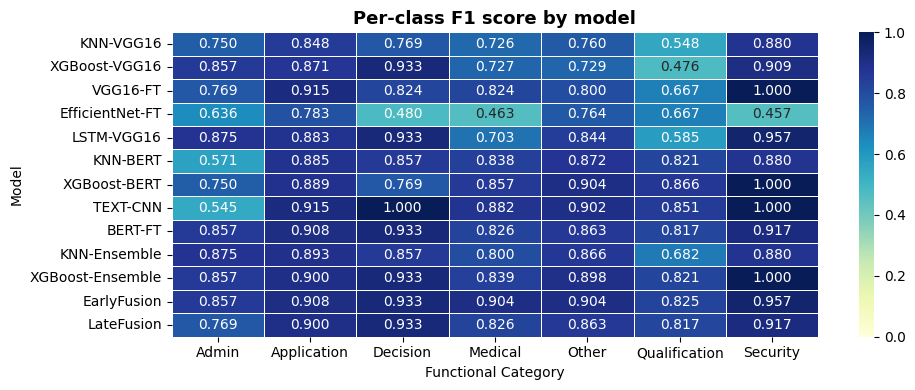

Figures saved.


In [68]:


# ── Per-class F1 heatmap ─────────────────────────────────────────────────────
f1_cols = [f'f1_{n}' for n in SHORT_NAMES]
f1_df   = summary_df[f1_cols].astype(float)
f1_df.columns = SHORT_NAMES

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(f1_df, annot=True, fmt='.3f', cmap='YlGnBu',
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Per-class F1 score by model', fontsize=13, fontweight='bold')
ax.set_xlabel('Functional Category')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig(WORKSPACE / 'func_start_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figures saved.')